# Notebook 06 - Coupled Piping-Structural Systems and Support Optimization

This lesson extends the pipe-only workflow into a coupled pipe-rack model. It loads Code_Aster-backed results for scoring, then shows how iterative support optimization can be enabled when a configured solver runtime is available.

You will do four things:

1. Build a portal frame and pipe crossing in one `TubaModel`.
2. Add a frictional rest support at the actual crossing node.
3. Score the design from Code_Aster-backed results.
4. Keep iterative optimization explicitly gated behind a solver-runtime flag.


## 1. Imports and Setup

In [1]:
import sys
from pathlib import Path
import numpy as np
import pyvista as pv

# Setup repo root for path import
REPO_ROOT = Path.cwd()
if REPO_ROOT.name.lower() == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from tuba import Model
from tuba.analysis.code_aster_notebook import configure_code_aster_notebook_runtime, load_or_run_code_aster_results
from tuba.plotting import plots

# Enable interactive notebook rendering
# Defaults to zoomable embedded HTML locally; set TUBA_NOTEBOOK_BACKEND=client or static to override.
from tuba.plotting.notebook import configure_notebook_backend
JUPYTER_BACKEND = configure_notebook_backend()

## 2. Building the Coupled Portal Frame + Piping Model

We'll build a structural portal frame at $X = 5.0$ meters:
- Two vertical columns modeled as beams using a box section profile (`ColBox`).
- One horizontal girder connecting the column tops modeled as an I-beam (`HE200B`).
- A piping system crossing directly over the girder at $Y = 3.1143$ meters with a frictional rest support.

The pipe run is still built with `PipingBuilder`, but the steel portal frame is easier to show with explicit node and beam calls. `model.add_node([x, y, z])` returns a generated node id. `model.add_element(..., n1=start_node, n2=end_node, ...)` connects two node ids; the beam vector is `coords(n2) - coords(n1)`.

In [ ]:
model = Model("StructuralDemo", standard="ASME_B31.3")

model.add_material(
    "S235JR",
    E=2.1e11,
    nu=0.3,
    alpha=1.2e-5,
    rho=7850.0,
    allowable_stress={20.0: 137e6, 200.0: 120e6},
)
model.add_pipe_section("4inch_sch40", OD=0.1143, WT=0.00602)
model.add_rectangular_section("ColBox", height_y=0.2, height_z=0.2, thickness_y=0.008, thickness_z=0.008)
model.add_ibeam_section("HE200B_Girder", "HE200B")

c1_base = model.add_node([5.0, 0.0, -1.0])
c1_top = model.add_node([5.0, 3.0, -1.0])
model.add_element(id="col_1", type="beam", n1=c1_base, n2=c1_top, section="ColBox", material="S235JR")
model.add_support(c1_base, "anchor")

c2_base = model.add_node([5.0, 0.0, 1.0])
c2_top = model.add_node([5.0, 3.0, 1.0])
model.add_element(id="col_2", type="beam", n1=c2_base, n2=c2_top, section="ColBox", material="S235JR")
model.add_support(c2_base, "anchor")

model.add_element(id="girder", type="beam", n1=c1_top, n2=c2_top, section="HE200B_Girder", material="S235JR")

frame_nodes = {
    "c1_base": c1_base,
    "c1_top": c1_top,
    "c2_base": c2_base,
    "c2_top": c2_top,
}
frame_elements = ("col_1", "col_2", "girder")

print("Frame node coordinates:")
for label, node_id in frame_nodes.items():
    print(f"  {label:<7} -> {node_id}: {model.nodes[node_id].coords.tolist()}")

print("Frame element endpoint vectors:")
for element_id in frame_elements:
    elem = model.get_element(element_id)
    start = model.nodes[elem.n1].coords
    end = model.nodes[elem.n2].coords
    print(f"  {elem.id}: n1={elem.n1}, n2={elem.n2}, vector={(end - start).tolist()}")

with model.pipe(section="4inch_sch40", material="S235JR") as b:
    b.start([0, 3.1143, 0], support="anchor")
    b.run(5.0)
    b.run(5.0)
    b.end(support="anchor")

pipe_crossing_node = next(
    nid for nid, node in model.nodes.items()
    if np.allclose(node.coords, [5.0, 3.1143, 0.0])
)
print(f"Crossing node over the girder: {pipe_crossing_node}")
print(f"Model has {len(model.nodes)} nodes and {len(model.elements)} elements.")


Attach the frictional rest to the computed crossing node directly above the structural girder.


In [3]:
model.add_support(pipe_crossing_node, type="rest", friction_coefficient=0.3)
model.define_load_case("Operating_Hot", gravity=True, pressure=2.5e6, temperature=220.0, ref_temperature=20.0)
print(f"Rest support attached to {pipe_crossing_node}.")


Rest support attached to N5.


### Visualizing the Coupled Structural-Piping Rack

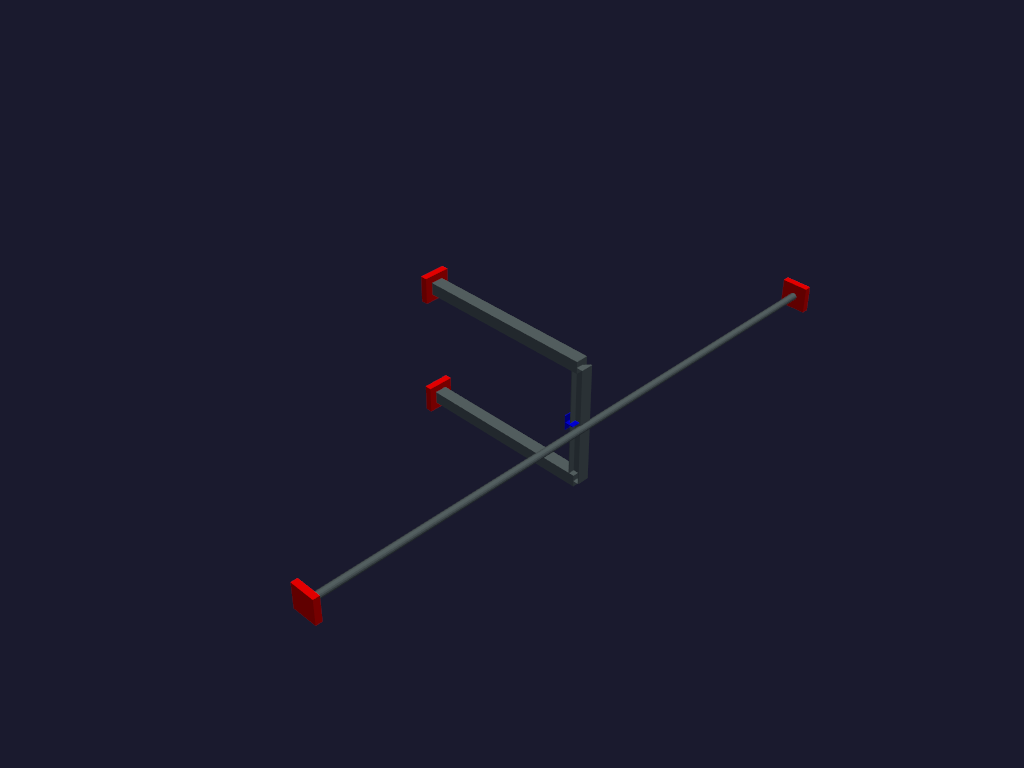

In [4]:
from tuba.plotting.pipeline import build_3d_mesh_from_model

# True section geometry — the box columns and I-beam girder show their real
# profiles straight from the model's sections, not uniform tubes.
tubes = build_3d_mesh_from_model(model)

p = pv.Plotter()
p.set_background("#1a1a2e")
p.add_mesh(tubes, color="#5c6b73")
plots._add_supports_to_plotter(p, model, scale=0.18)
p.show(jupyter_backend=JUPYTER_BACKEND)

## 3. Multi-Objective Design Evaluation

Engineering optimization requires balancing multiple competing objectives.
Tuba provides an `ObjectiveEvaluator` class that aggregates design penalties for:
1. **Stress:** Violations of ASME B31.3 allowable limits.
2. **Deflection:** Sag displacements exceeding the 2.5 mm limit.
3. **Support Cost:** Support counts and complexity metrics.
4. **Clash:** Interference checks against obstacles.

In [5]:
from tuba.optimization.objectives import (
    ObjectiveEvaluator,
    StressObjective,
    DeflectionObjective,
    SupportCostObjective,
    ClashObjective,
)

# Create the evaluator
evaluator = ObjectiveEvaluator([
    StressObjective(weight=1.0),
    DeflectionObjective(weight=2.0),
    SupportCostObjective(weight=0.5),
    ClashObjective(weight=3.0),
])

CODE_ASTER_RUNTIME = configure_code_aster_notebook_runtime()
# VS Code/Jupyter review defaults to committed real Code_Aster artifacts; set True only after the runtime doctor passes.
RUN_CODE_ASTER = False
CODE_ASTER_WORK_DIR = REPO_ROOT / "notebooks" / "code_aster_results" / "structural_operating_hot"

code_aster_run = load_or_run_code_aster_results(
    model,
    "Operating_Hot",
    CODE_ASTER_WORK_DIR,
    run_solver=RUN_CODE_ASTER,
    exec_method=CODE_ASTER_RUNTIME.exec_method,
    wsl_distro=CODE_ASTER_RUNTIME.wsl_distro,
    docker_image=CODE_ASTER_RUNTIME.docker_image,
)
results = code_aster_run.results
code_aster_artifact = code_aster_run.artifact

if code_aster_run.ran_solver:
    print("Code_Aster solver executed for this notebook run.")
scores = evaluator.get_detailed_scores(model, results)
print("Multi-objective score breakdown from Code_Aster results:")
for obj_name, info in scores.items():
    if isinstance(info, dict):
        print(f"  {obj_name}: Penalty = {info['score']:.3f}, Details = {info['details']}")
    else:
        print(f"  {obj_name}: {info:.3f}")

Failed to read .rmed: Could not deduce file format from path 'D:\Gitprojects\Tuba_v4\notebooks\code_aster_results\structural_operating_hot\study.rmed'.


Multi-objective score breakdown from Code_Aster results:
  StressObjective: Penalty = 1.019, Details = {'max_stress_ratio': 0.25481098343635983, 'worst_element': 'pipe_str_0', 'pass': True}
  DeflectionObjective: Penalty = 1086.927, Details = {'max_deflection_mm': 7.585542296375388, 'worst_node': 'N1', 'within_limit': False}
  SupportCostObjective: Penalty = 4.500, Details = {'support_counts': {'anchor': 4, 'rest': 1}, 'total_supports': 5}
  ClashObjective: Penalty = 0.000, Details = {'colliding_elements': [], 'collision_count': 0, 'clean': True}
  TotalScore: 1092.446


## 4. Solver-Scored Support Optimization

Tuba does not generate heuristic support layouts. Define supports explicitly, then use a solver-scored search only when every candidate can run through Code_Aster.


In [6]:
opt_model = model
opt_res = results
print("Explicit supports and the loaded Code_Aster result set remain authoritative.")

Explicit supports and the loaded Code_Aster result set remain authoritative.


## Key Takeaways

- Mixed structural and piping elements can live in one `TubaModel`.
- The scoring cell uses Code_Aster-backed results loaded through the shared notebook helper.
- Iterative optimization is explicitly gated because it runs repeated solver jobs.

Next: `07_bim_data_exchange.ipynb` exports the model and solver properties into data-exchange formats.
